# Training KongNet from Scratch on CoNIC


## About this notebook

This notebook demonstrates the new structured-dense training workflow in `tiatoolbox.models.training` using a KongNet model trained from scratch on the CoNIC patch dataset.

Workflow used here:
1. Load the PNG patches and paired annotation stores created from CoNIC `images.npy` and `labels.npy`.
2. Build a full 3-channel supervision target for each CoNIC class head: `mask`, `boundary`, and `centroid`.
3. Instantiate KongNet and derive a `StructuredDenseTask` with `build_kongnet_training_task()`.
4. Train for a few epochs on a small demo subset.
5. Run inference on a few validation patches and visualise the learned mask, boundary, centroid, and peak outputs.

This is intentionally a lightweight demonstration. Challenge-grade KongNet training would use the full dataset, more augmentation, larger batches, and substantially more epochs.


## Optional: Colab setup


In [ ]:
%%bash
python -m pip install --quiet --upgrade pip
python -m pip install --quiet tiatoolbox


If you are using Colab and ran the install cell for the first time, restart the runtime before continuing.


## Imports and configuration


In [1]:
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tiatoolbox.data import small_svs
from tiatoolbox.models.architecture.kongnet import KongNet, KongNetSegmentor
from tiatoolbox.models.engine.io_config import IOSegmentorConfig
from tiatoolbox.models.engine.multi_task_segmentor import MultiTaskSegmentor
from tiatoolbox.models.training import (
    BoundaryTargetBuilder,
    CompositeTargetBuilder,
    GaussianHeatmapTargetBuilder,
    MaskTargetBuilder,
    PatchAnnotationDataset,
    StackedTargetBuilder,
    Trainer,
    TrainerConfig,
    TrainingArtifactManifest,
    make_dataloaders,
    build_kongnet_training_task,
    get_annotation_augmentation,
)
from tiatoolbox.utils.visualization import AnnotationRenderer
from tiatoolbox.wsicore.wsireader import AnnotationStoreReader, WSIReader

rng = np.random.default_rng(7)
torch.manual_seed(7)

SUPERVISION_CHANNELS = ("mask", "boundary", "centroid")

device = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.dpi"] = 140

def load_rgb_image(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def stack_head_channel_maps(
    target_dict: dict[str, torch.Tensor],
    ordered_keys: list[str],
    channel_index: int,
) -> np.ndarray:
    return np.stack(
        [target_dict[key][channel_index].cpu().numpy() for key in ordered_keys],
        axis=-1,
    )

def extract_kongnet_head_channel_maps(
    model: KongNet,
    logits: torch.Tensor,
    ordered_keys: list[str],
) -> dict[str, np.ndarray]:
    probabilities = torch.sigmoid(logits).detach().cpu()
    head_specs = {spec.name: spec for spec in model.training_output_spec}
    channel_maps = {channel_name: [] for channel_name in SUPERVISION_CHANNELS}

    for head_key in ordered_keys:
        head_spec = head_specs[head_key]
        head_probabilities = probabilities[:, head_spec.channel_slice, :, :]
        for channel_index, channel_name in enumerate(SUPERVISION_CHANNELS):
            channel_maps[channel_name].append(head_probabilities[:, channel_index].numpy())

    return {
        channel_name: np.stack(head_maps, axis=-1)
        for channel_name, head_maps in channel_maps.items()
    }


|2026-05-15|03:49:44.996| [WARNING] /home/mark-eastwood/miniforge3/envs/comfyui/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Locate the converted CoNIC data

This notebook assumes you already ran `examples/prepare_conic_training_data.py`, which should have created:
- `images_png/` containing one PNG patch per CoNIC sample
- `annotation_stores/` containing one `.db` store per PNG patch


In [2]:
data_root = Path("/media/mark-eastwood/Work/Data/Conic")
images_dir = data_root / "images_png"
stores_dir = data_root / "annotation_stores"

if not images_dir.exists() or not stores_dir.exists():
    raise FileNotFoundError(
        "Expected `images_png/` and `annotation_stores/` inside the CoNIC directory. "
        "Run `examples/prepare_conic_training_data.py` first."
    )


## Define a compact KongNet supervision recipe

KongNet has 6 heads on CoNIC, with 3 output channels per head in the pretrained architecture. In this example we supervise all 3 channels of every head:

- `mask`: dense per-class foreground map
- `boundary`: dense contour map
- `centroid`: dense Gaussian detection heatmap


In [3]:
conic_class_dict = {
    0: "Neutrophil",
    1: "Epithelial",
    2: "Lymphocyte",
    3: "Plasma",
    4: "Eosinophil",
    5: "Connective",
}
conic_engine_class_dict = {
    class_id + 1: label for class_id, label in conic_class_dict.items()
}
ordered_head_keys = [label.lower() for label in conic_class_dict.values()]

target_builder = CompositeTargetBuilder(
    {
        label.lower(): StackedTargetBuilder(
            {
                "mask": MaskTargetBuilder(
                    class_mapping=None,
                    default_label=0,
                ),
                "boundary": BoundaryTargetBuilder(line_width=1),
                "centroid": GaussianHeatmapTargetBuilder(sigma=2.0),
            },
            where=f'props["class"] == "{label}"',
        )
        for label in conic_class_dict.values()
    }
)

paired_dataset = PatchAnnotationDataset.from_dirs(
    patch_dir=images_dir,
    annotation_store_dir=stores_dir,
    target_builder=target_builder,
)
print(f"Found {len(paired_dataset)} PNG/store pairs.")

train_augmentation = get_annotation_augmentation(
    "light",
    target_builder=target_builder,
)

demo_train_size = 4096
demo_val_size = 768
demo_size = demo_train_size + demo_val_size

demo_indices = rng.permutation(len(paired_dataset))[:demo_size]
train_indices = demo_indices[:demo_train_size]
val_indices = demo_indices[demo_train_size:]

print(f"Demo train pairs: {len(train_indices)}")
print(f"Demo val pairs: {len(val_indices)}")


Found 4981 PNG/store pairs.
Demo train pairs: 4096
Demo val pairs: 768


## Build datasets and preview one target sample


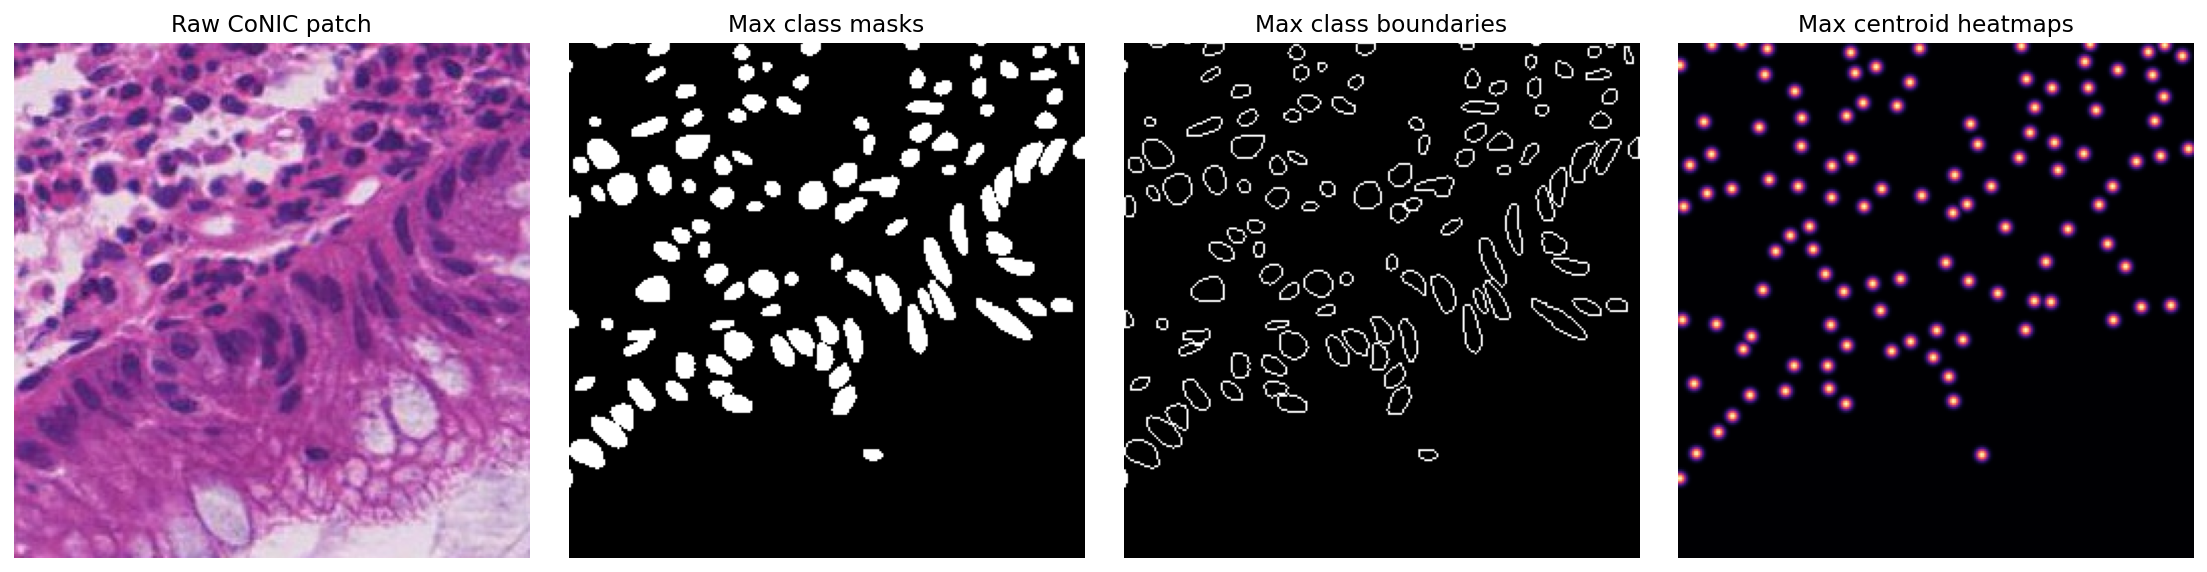

In [4]:
train_base_dataset = PatchAnnotationDataset.from_dirs(
    patch_dir=images_dir,
    annotation_store_dir=stores_dir,
    target_builder=target_builder,
    pair_transform=train_augmentation.pair_transform,
    image_transform=KongNet.preproc,
)
train_dataset = torch.utils.data.Subset(train_base_dataset, train_indices.tolist())

val_base_dataset = PatchAnnotationDataset.from_dirs(
    patch_dir=images_dir,
    annotation_store_dir=stores_dir,
    target_builder=target_builder,
    image_transform=KongNet.preproc,
)
val_dataset = torch.utils.data.Subset(val_base_dataset, val_indices.tolist())

preview_image_path = val_base_dataset.patch_inputs[val_indices[0]]
preview_raw = load_rgb_image(preview_image_path)
preview_item = val_dataset[0]
preview_mask_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 0)
preview_boundary_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 1)
preview_centroid_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(preview_raw)
axes[0].set_title("Raw CoNIC patch")
axes[1].imshow(np.max(preview_mask_maps, axis=-1), cmap="gray")
axes[1].set_title("Max class masks")
axes[2].imshow(np.max(preview_boundary_maps, axis=-1), cmap="gray")
axes[2].set_title("Max class boundaries")
axes[3].imshow(np.max(preview_centroid_maps, axis=-1), cmap="magma")
axes[3].set_title("Max centroid heatmaps")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


## Instantiate KongNet and derive the structured dense task

We keep KongNet's native 3-channel-per-head layout and supervise each head as a single stacked dense target.


In [5]:
model = KongNet(
    num_heads=6,
    num_channels_per_head=[3, 3, 3, 3, 3, 3],
    target_channels=[2, 5, 8, 11, 14, 17],
    min_distance=5,
    threshold_abs=0.35,
    class_dict=conic_class_dict,
)

task = build_kongnet_training_task(
    model,
    target_selection="full_head",
)

pd.DataFrame(
    [
        {
            "head": spec.name,
            "display_name": spec.display_name,
            "channel_slice": str(spec.channel_slice),
            "target_channels": list(spec.target_channels),
            "target_offsets": list(spec.target_channel_offsets),
        }
        for spec in model.training_output_spec
    ]
)


,head,display_name,channel_slice,target_channels,target_offsets
0,neutrophil,Neutrophil,"slice(0, 3, None)",[2],[2]
1,epithelial,Epithelial,"slice(3, 6, None)",[5],[2]
2,lymphocyte,Lymphocyte,"slice(6, 9, None)",[8],[2]
3,plasma,Plasma,"slice(9, 12, None)",[11],[2]
4,eosinophil,Eosinophil,"slice(12, 15, None)",[14],[2]
5,connective,Connective,"slice(15, 18, None)",[17],[2]


## Data loaders and a trainer run

We will now run a training run which should take ~15 mins on a good GPU. Reduce epochs accordingly for a shorter run or on weaker GPU, but inference visualizations may look poor.

The `TrainingArtifactManifest` records the pieces needed to hand this trained model to an inference engine: where the weights are saved, how to rebuild the model, the preprocessing/post-processing entry points, the output resolution, and the class labels. `artifact.to_engine_setup("MultiTaskSegmentor")` turns that manifest into two groups of arguments: constructor arguments such as `weights`, and run-time arguments such as the IO configuration and class dictionary. This makes the training notebook produce a reusable inference setup instead of a loose checkpoint file.


In [6]:
batch_size = 8

train_loader, val_loader = make_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=batch_size,
    num_workers=4,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

train_output_dir = Path("examples/tmp/15-kongnet-conic-training")
if train_output_dir.exists():
    shutil.rmtree(train_output_dir)

artifact_ioconfig = IOSegmentorConfig(
    input_resolutions=[{"units": "baseline", "resolution": 1.0}],
    output_resolutions=[{"units": "baseline", "resolution": 1.0}],
    patch_input_shape=preview_raw.shape[:2],
    patch_output_shape=preview_raw.shape[:2],
    stride_shape=preview_raw.shape[:2],
    tile_shape=tuple(int(size * 4) for size in preview_raw.shape[:2]),
    margin=max(1, int(min(preview_raw.shape[:2]) // 8)),
)

training_artifact = TrainingArtifactManifest.from_model(
    model,
    task_type="multi_task_segmentation",
    model_constructor={
        "num_heads": 6,
        "num_channels_per_head": [3, 3, 3, 3, 3, 3],
        "target_channels": [2, 5, 8, 11, 14, 17],
        "min_distance": 5,
        "threshold_abs": 0.35,
    },
    class_dict={"nuclei_segmentation": conic_engine_class_dict},
    preprocessing={"name": "KongNet.preproc"},
    postprocessing={"name": "KongNetSegmentor.postproc"},
    ioconfig=artifact_ioconfig,
    engine="MultiTaskSegmentor",
    metadata={
        "ordered_head_keys": ordered_head_keys,
        "engine_class_dict": conic_engine_class_dict,
    },
)

trainer = Trainer(
    model=model,
    task=task,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=30,
        seed=7,
        output_dir=train_output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
    artifact_manifest=training_artifact,
)

history = trainer.fit()
history_df = pd.DataFrame(history)
history_df.tail()


artifact = TrainingArtifactManifest.load(train_output_dir / "training_artifact.json")
engine_setup = artifact.to_engine_setup("MultiTaskSegmentor")
print("Saved artifact weights:", artifact.weights)
print("Engine constructor kwargs:", engine_setup.constructor_kwargs)
print("Engine run kwargs:", sorted(engine_setup.run_kwargs))


|2026-05-15|03:51:09.606| [INFO] Epoch 1/30 | monitor `val_loss`=3.325123 | best=3.325123
|2026-05-15|03:52:25.474| [INFO] Epoch 2/30 | monitor `val_loss`=3.156401 | best=3.156401
|2026-05-15|03:53:41.164| [INFO] Epoch 3/30 | monitor `val_loss`=1.750937 | best=1.750937
|2026-05-15|03:54:56.794| [INFO] Epoch 4/30 | monitor `val_loss`=1.043012 | best=1.043012
|2026-05-15|03:56:12.538| [INFO] Epoch 5/30 | monitor `val_loss`=0.635921 | best=0.635921
|2026-05-15|03:57:28.229| [INFO] Epoch 6/30 | monitor `val_loss`=0.458044 | best=0.458044
|2026-05-15|03:58:43.845| [INFO] Epoch 7/30 | monitor `val_loss`=0.353097 | best=0.353097
|2026-05-15|03:59:58.940| [INFO] Epoch 8/30 | monitor `val_loss`=0.287595 | best=0.287595
|2026-05-15|04:01:14.282| [INFO] Epoch 9/30 | monitor `val_loss`=0.249847 | best=0.249847
|2026-05-15|04:02:29.090| [INFO] Epoch 10/30 | monitor `val_loss`=0.222560 | best=0.222560
|2026-05-15|04:03:44.880| [INFO] Epoch 11/30 | monitor `val_loss`=0.203360 | best=0.203360
|2026-05

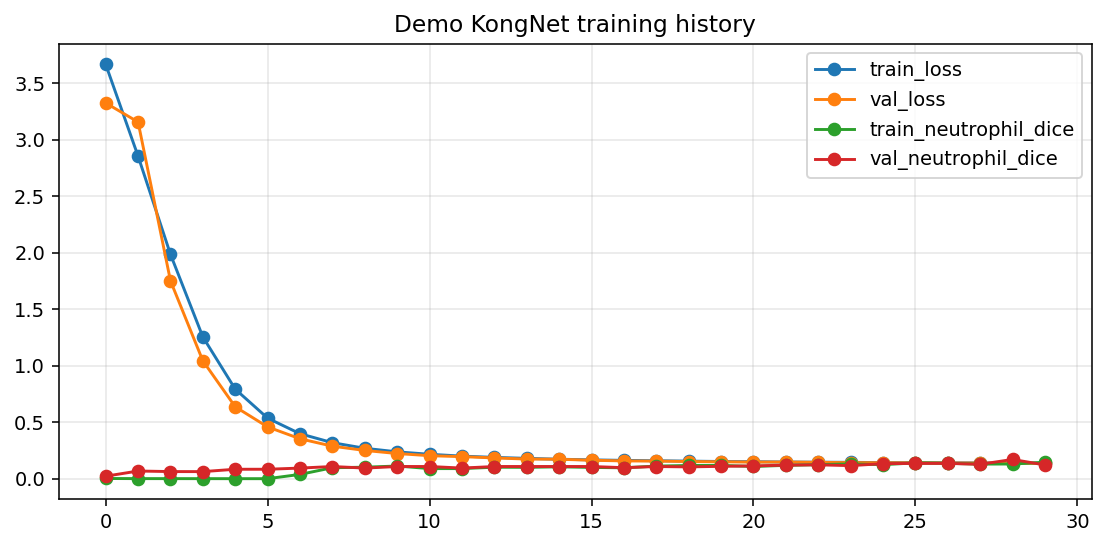

In [7]:
metric_columns = ["train_loss", "val_loss"]
if "train_neutrophil_dice" in history_df:
    metric_columns.extend(["train_neutrophil_dice", "val_neutrophil_dice"])

history_df[metric_columns].plot(marker="o", figsize=(8, 4))
plt.title("Demo KongNet training history")
plt.grid(alpha=0.3)
plt.tight_layout()


## Inference on a few validation patches

We run the newly trained model on a few held-out CoNIC patches, inspect the learned mask, boundary, and centroid probability maps, and then apply KongNet's centroid post-processing to obtain per-class peak detections.


|2026-05-15|04:27:49.048| [WARNING] /media/mark-eastwood/Work/tiatoolbox/tiatoolbox/models/architecture/utils.py:499: FutureWarning: `RegionProperties['mean_intensity']` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties['intensity_mean']` instead. 
  peak["mean_intensity"],

|2026-05-15|04:27:49.180| [WARNING] /tmp/ipykernel_43798/2157332047.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap = plt.cm.get_cmap("tab10", len(ordered_head_keys))



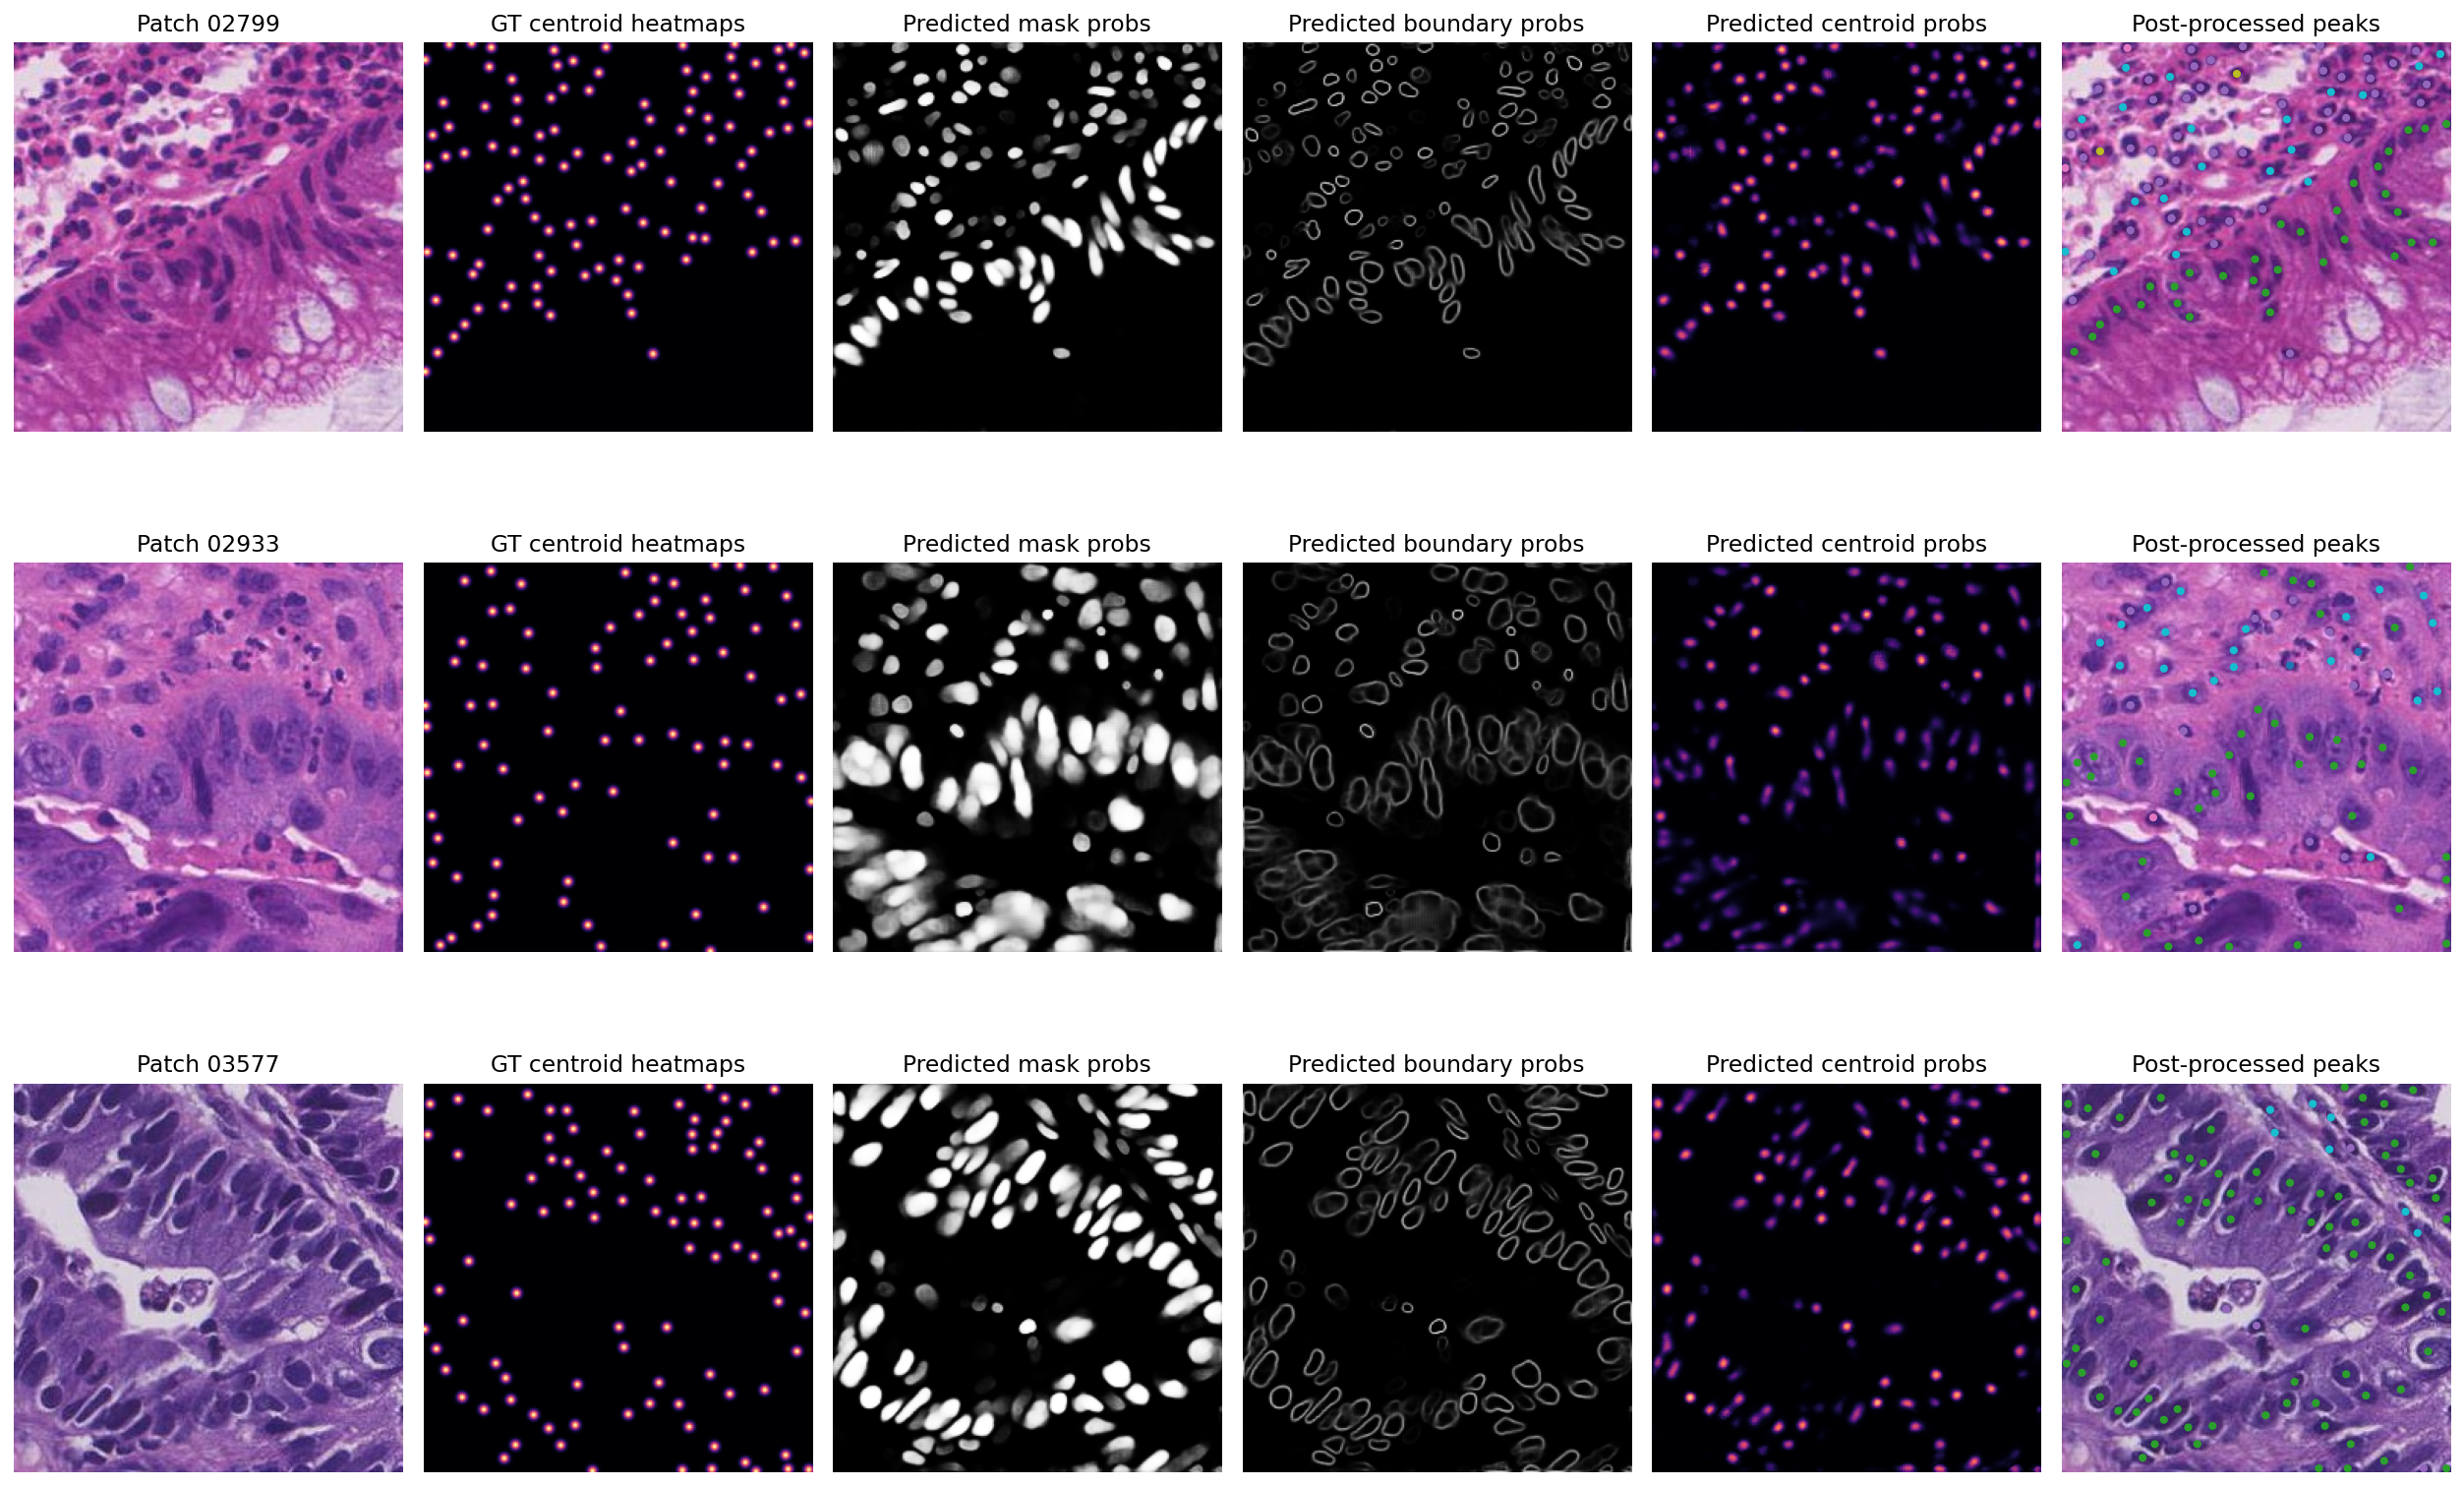

In [8]:
model.eval()

example_count = 3
example_indices = val_indices[:example_count]
example_image_paths = [val_base_dataset.patch_inputs[index] for index in example_indices]
example_images = [load_rgb_image(image_path) for image_path in example_image_paths]
example_batch = torch.from_numpy(
    np.stack([KongNet.preproc(image).astype(np.float32) for image in example_images], axis=0)
)
example_batch_nchw = example_batch.permute(0, 3, 1, 2).to(device)

with torch.no_grad():
    example_logits = model(example_batch_nchw)

pred_component_maps = extract_kongnet_head_channel_maps(model, example_logits, ordered_head_keys)
pred_centroid_maps = pred_component_maps["centroid"]
pred_peak_maps = np.stack([model.postproc(prob_map) for prob_map in pred_centroid_maps], axis=0)
gt_centroid_maps = [
    stack_head_channel_maps(val_dataset[index]["target"], ordered_head_keys, 2)
    for index in range(example_count)
]

class_cmap = plt.cm.get_cmap("tab10", len(ordered_head_keys))
class_colours = {key: class_cmap(index) for index, key in enumerate(ordered_head_keys)}

fig, axes = plt.subplots(example_count, 6, figsize=(18, 4 * example_count))
if example_count == 1:
    axes = np.expand_dims(axes, axis=0)

for row, image in enumerate(example_images):
    peak_map = pred_peak_maps[row]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Patch {Path(example_image_paths[row]).stem}")

    axes[row, 1].imshow(np.max(gt_centroid_maps[row], axis=-1), cmap="magma")
    axes[row, 1].set_title("GT centroid heatmaps")

    axes[row, 2].imshow(np.max(pred_component_maps["mask"][row], axis=-1), cmap="gray", vmin=0.0, vmax=1.0)
    axes[row, 2].set_title("Predicted mask probs")

    axes[row, 3].imshow(np.max(pred_component_maps["boundary"][row], axis=-1), cmap="gray", vmin=0.0, vmax=1.0)
    axes[row, 3].set_title("Predicted boundary probs")

    axes[row, 4].imshow(np.max(pred_component_maps["centroid"][row], axis=-1), cmap="magma", vmin=0.0, vmax=1.0)
    axes[row, 4].set_title("Predicted centroid probs")

    axes[row, 5].imshow(image)
    peak_y, peak_x, peak_c = np.where(peak_map > 0)
    if len(peak_x) > 0:
        axes[row, 5].scatter(
            peak_x,
            peak_y,
            c=[class_colours[ordered_head_keys[channel]] for channel in peak_c],
            s=10,
        )
    axes[row, 5].set_title("Post-processed peaks")

    for col in range(6):
        axes[row, col].axis("off")

plt.tight_layout()


In [9]:
peak_count_rows = []
for row, image_path in enumerate(example_image_paths):
    row_counts = {"patch": Path(image_path).stem}
    for channel_index, head_key in enumerate(ordered_head_keys):
        row_counts[head_key] = int(pred_peak_maps[row, :, :, channel_index].sum())
    peak_count_rows.append(row_counts)

pd.DataFrame(peak_count_rows)


,patch,neutrophil,epithelial,lymphocyte,plasma,eosinophil,connective
0,02799,0,21,28,0,0,12
1,02933,0,18,8,0,0,12
2,03577,0,51,2,0,0,4


## Instance segmentation post-processing on patches

The peak map only shows where the model expects nuclei centroids. The segmentation-capable post-processing combines the predicted mask, boundary, and centroid maps to seed a watershed, assigns each instance to a CoNIC class head, and returns instance polygons that the engine can later save to an `AnnotationStore`.


,patch,neutrophil,epithelial,lymphocyte,plasma,eosinophil,connective
0,02799,0,35,43,3,2,20
1,02933,6,67,13,1,0,24
2,03577,0,88,3,0,0,9


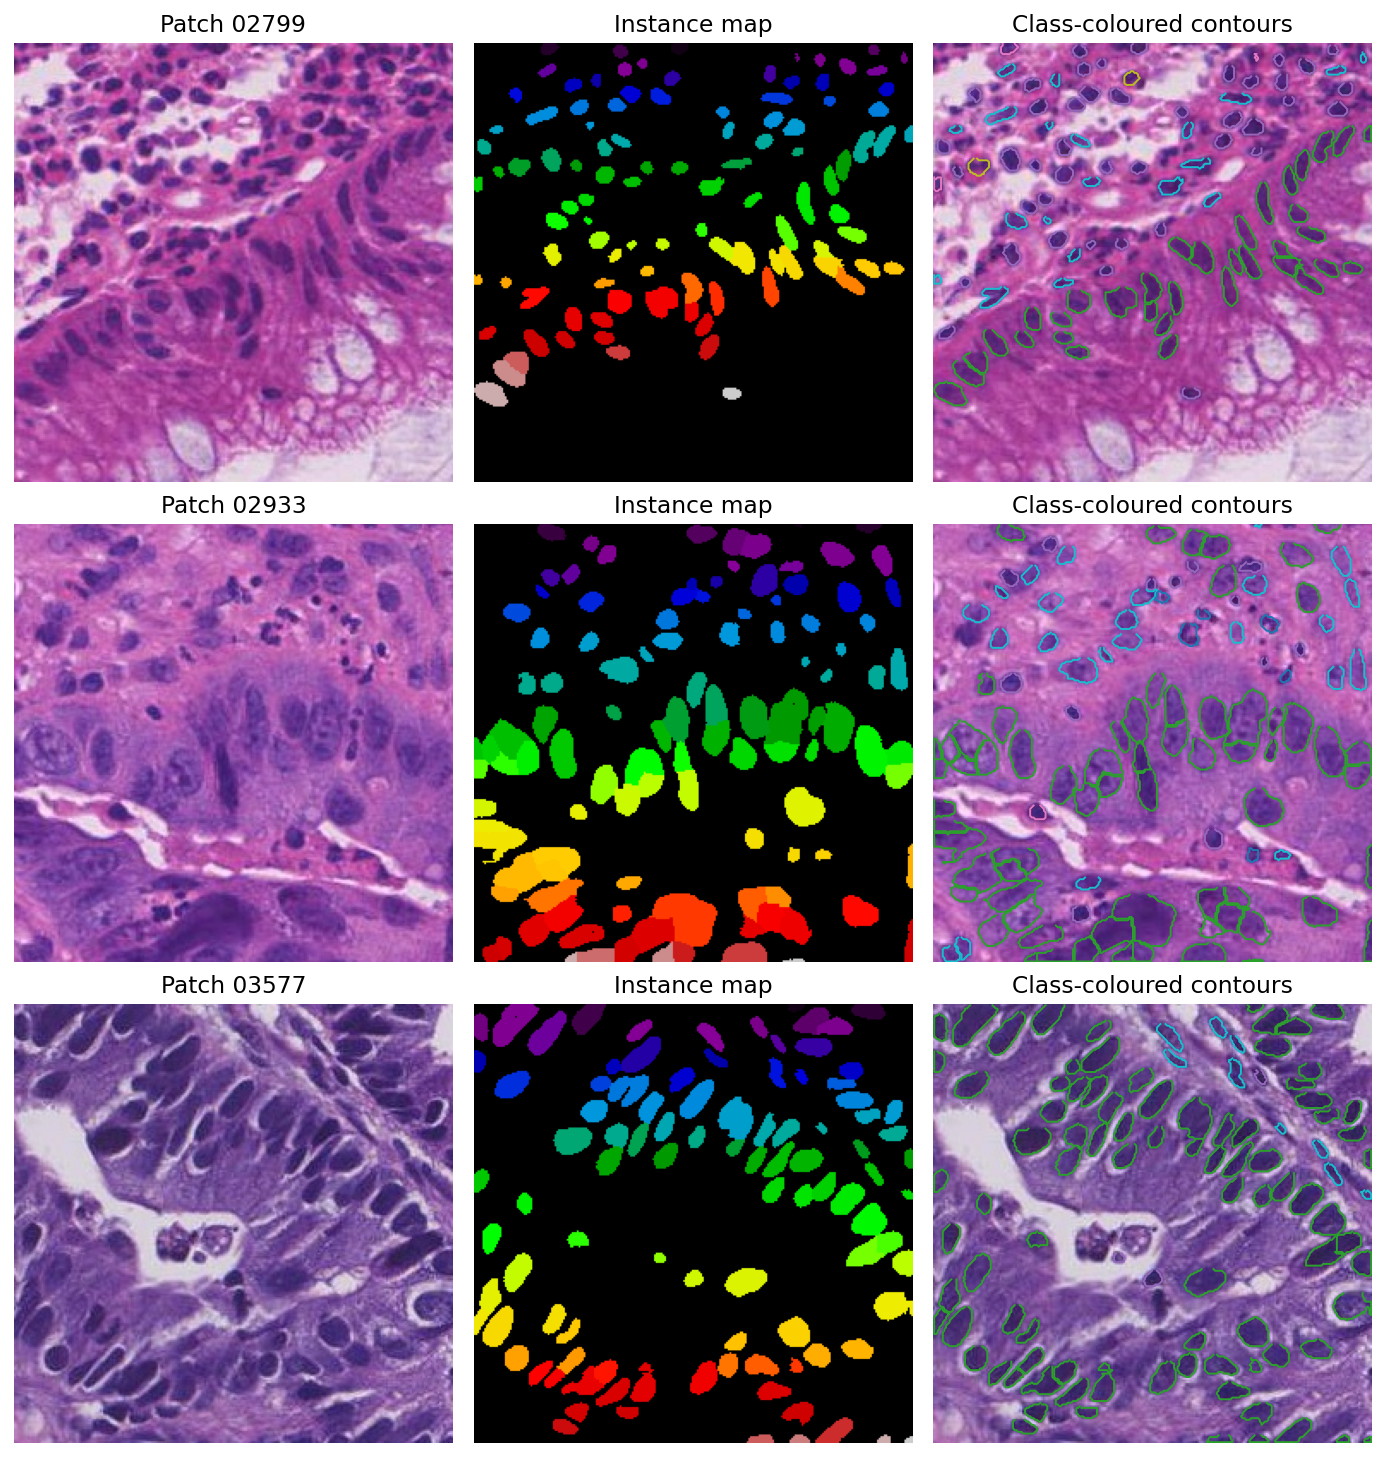

In [20]:
example_probability_maps = (
    torch.sigmoid(example_logits)
    .detach()
    .cpu()
    .permute(0, 2, 3, 1)
    .numpy()
)
instance_results = [
    model.postproc_instance_class_maps(
        probability_map,
        threshold_abs=0.2,
        from_logits=False,
        mask_threshold=0.35,
        min_instance_size=8,
        boundary_weight=1.0,
    )
    for probability_map in example_probability_maps
]

fig, axes = plt.subplots(example_count, 3, figsize=(10, 3.5 * example_count))
if example_count == 1:
    axes = np.expand_dims(axes, axis=0)

instance_summary_rows = []
for row, (image, result) in enumerate(zip(example_images, instance_results, strict=True)):
    instance_map = result.instance_map
    patch_name = Path(example_image_paths[row]).stem

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Patch {patch_name}")

    axes[row, 1].imshow(instance_map, cmap="nipy_spectral")
    axes[row, 1].set_title("Instance map")

    axes[row, 2].imshow(image)
    axes[row, 2].set_title("Class-coloured contours")
    for instance_id, class_id in result.instance_classes.items():
        instance_mask = (instance_map == instance_id).astype(np.uint8)
        contours, _ = cv2.findContours(
            instance_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )
        if not contours:
            continue
        class_index = int(class_id) - 1
        if not 0 <= class_index < len(ordered_head_keys):
            continue
        class_key = ordered_head_keys[class_index]
        contour = max(contours, key=cv2.contourArea)[:, 0, :]
        axes[row, 2].plot(
            contour[:, 0],
            contour[:, 1],
            color=class_colours[class_key],
            linewidth=1.0,
        )

    row_counts = {"patch": patch_name}
    for class_index, head_key in enumerate(ordered_head_keys, start=1):
        row_counts[head_key] = sum(
            class_id == class_index
            for class_id in result.instance_classes.values()
        )
    instance_summary_rows.append(row_counts)

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
pd.DataFrame(instance_summary_rows)


## Use the artifact for WSI inference

The earlier patch-level cells are useful for inspecting the training output directly. To use the saved training artifact in the same way a downstream script would, load the artifact, convert it to engine arguments, rebuild a segmentation-capable `KongNetSegmentor`, and run the `MultiTaskSegmentor` on a small sample WSI. This produces an `AnnotationStore` of cell polygons that can be rendered over the slide.

This model was trained only for a short instructional run, so the overlay is a workflow demonstration rather than a recommended production result.


In [ ]:
wsi_path = Path(small_svs())
inference_dir = train_output_dir / "small_svs_inference"

artifact = TrainingArtifactManifest.load(train_output_dir / "training_artifact.json")
engine_setup = artifact.to_engine_setup("MultiTaskSegmentor")
artifact_ioconfig = engine_setup.run_kwargs["ioconfig"]
if artifact_ioconfig.tile_shape is None:
    artifact_ioconfig.tile_shape = tuple(
        int(size * 4) for size in artifact_ioconfig.patch_output_shape
    )
if artifact_ioconfig.margin is None or artifact_ioconfig.margin <= 0:
    artifact_ioconfig.margin = max(
        1,
        int(min(artifact_ioconfig.patch_output_shape) // 8),
    )

artifact.model["constructor"]["threshold_abs"] = 0.1
segmentor_model = KongNetSegmentor(
    **artifact.model["constructor"],
    class_dict=conic_class_dict,
)
segmentor = MultiTaskSegmentor(
    model=segmentor_model,
    batch_size=1,
    num_workers=4,
    device=device,
    **engine_setup.constructor_kwargs,
)

wsi_outputs = segmentor.run(
    images=[wsi_path],
    patch_mode=False,
    save_dir=inference_dir,
    output_type="annotationstore",
    overwrite=True,
    auto_get_mask=True,
    memory_threshold=60,
    return_predictions=(False,),
    return_probabilities=False,
    **engine_setup.run_kwargs,
)

annotation_store_path = Path(wsi_outputs[wsi_path][0])
annotation_store_path


In [11]:
engine_setup.run_kwargs

{'ioconfig': IOSegmentorConfig(input_resolutions=[{'resolution': 1.0, 'units': 'baseline'}], patch_input_shape=[256, 256], stride_shape=[256, 256], output_resolutions=[{'resolution': 1.0, 'units': 'baseline'}], ignore_index=[None], patch_output_shape=[256, 256], save_resolution=None, tile_shape=[1024, 1024], margin=32),
 'class_dict': {'nuclei_segmentation': {1: 'Neutrophil',
   2: 'Epithelial',
   3: 'Lymphocyte',
   4: 'Plasma',
   5: 'Eosinophil',
   6: 'Connective'}}}

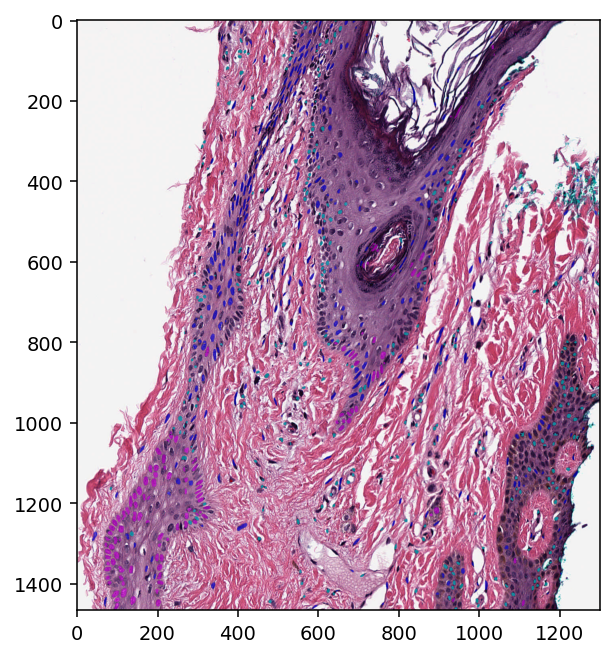

In [25]:
wsi_reader = WSIReader.open(wsi_path)
renderer = AnnotationRenderer(
    "type",
    list(conic_engine_class_dict.values()),
    max_scale=1000,
    edge_thickness=1,
)
annotation_reader = AnnotationStoreReader.open(
    annotation_store_path,
    base_wsi=wsi_reader,
    renderer=renderer,
    alpha=0.5,
)

ax = plt.imshow(annotation_reader.read_bounds(
    (500, 1500, 1800, wsi_reader.info.slide_dimensions[1]),
    resolution=20,
    units="power",
))
#ax.set_title("KongNetSegmentor annotations")
#ax.axis("off")
plt.tight_layout()


In [13]:
wsi_reader.info.mpp

array([0.499, 0.499])